In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import holidays

# Model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from xgboost import XGBRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings 
warnings.filterwarnings("ignore")

import joblib

import shap

In [8]:
data = pd.read_csv('/Users/naaani/Documents/unigap/forecasting/data/data_processing.csv',index_col=0)
data.head(4)

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0
2,2021-01-01,67LPLP,2576.0,100943.14,72128.00,1,1,4,53,0
3,2021-01-01,6HSD4J,1078.0,52806.91,33806.08,1,1,4,53,0


### 1. Prepare the features:

#### add temporal learning features: 

In [9]:
data['lag1'] = data.groupby('sku')['qty'].shift(1)
data['lag7'] = data.groupby('sku')['qty'].shift(7)
data['lag30'] = data.groupby('sku')['qty'].shift(30)
data['rolling_mean_7'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=7,min_periods=1).mean())
data['rolling_mean_30'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=30,min_periods=1).mean())   
data['rolling_std_7'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=7,min_periods=1).std())
data['rolling_std_30'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=30,min_periods=1).std())

data.head()

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0,NaN,NaN,NaN,5822.0,5822.0,NaN,NaN
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0,NaN,NaN,NaN,984.0,984.0,NaN,NaN
2,2021-01-01,67LPLP,2576.0,100943.14,72128.00,1,1,4,53,0,NaN,NaN,NaN,2576.0,2576.0,NaN,NaN
3,2021-01-01,6HSD4J,1078.0,52806.91,33806.08,1,1,4,53,0,NaN,NaN,NaN,1078.0,1078.0,NaN,NaN
4,2021-01-01,7XL27C,306.0,55490.65,17564.40,1,1,4,53,0,NaN,NaN,NaN,306.0,306.0,NaN,NaN


#### add features of SKU:

In [10]:
data_test = data.copy()

data_test["shipped_date"] = pd.to_datetime(data_test["shipped_date"])
data_test = data_test.sort_values(["sku", "shipped_date"])

data_test["dow"] = data_test["shipped_date"].dt.weekday  # 0 = Monday

data_test["mean_qty_sku_dow"] = (
    data_test.groupby(["sku", "dow"])["qty"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

data_test["month"] = data_test["shipped_date"].dt.month

data_test["mean_qty_sku_month"] = (
    data_test.groupby(["sku", "month"])["qty"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

#### transform qty to log(qty) to avoid the scale with 0

In [11]:
data_model = data_test.copy()
data_model["qty_log"] = np.log1p(data_model["qty"])  # log(1 + qty) 

data_model = data_model.sort_values("shipped_date")

split_idx = int(len(data_model) * 0.8)

train = data_model.iloc[:split_idx]
test  = data_model.iloc[split_idx:]
print(train.shape)
print(test.shape)

(2936, 21)
(734, 21)


In [12]:
train_model = train.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])
test_model = test.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])

#### normalize train/test 

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = train_model.drop(columns=["qty_log"])
y_train = train_model["qty_log"]

X_test = test_model.drop(columns=["qty_log"])
y_test = test_model["qty_log"]

X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 2. Apply the model: 

#### Random Forest (baseline)

In [14]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf_exp = np.expm1(y_pred_rf)

In [16]:
#evaluate: 
r2 = r2_score(np.expm1(y_test), y_pred_rf_exp)
mae = mean_absolute_error(np.expm1(y_test), y_pred_rf_exp)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_rf_exp))
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.7029
MAE: 453.2619
RMSE: 1152.7528


In [17]:
test['qty_pred'] = y_pred_rf_exp

##### Evaluate on each SKU: 

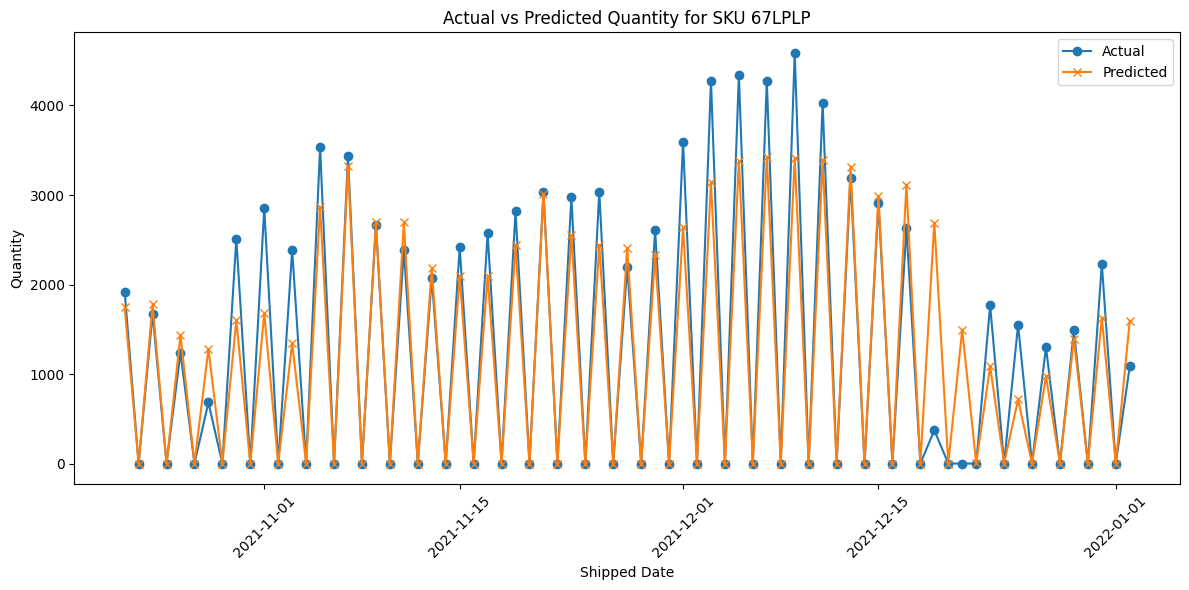

In [18]:
plot_df = test[test['sku'] == '4OCITK']
plt.figure(figsize=(12, 6))
plt.plot(plot_df['shipped_date'], plot_df['qty'], label='Actual', marker='o')
plt.plot(plot_df['shipped_date'], plot_df['qty_pred'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Quantity for SKU 67LPLP')
plt.xlabel('Shipped Date')
plt.ylabel('Quantity')
plt.legend()    
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Interpret Random Forest features: 

In [ ]:
importance = rf_model.feature_importances_

# Convert thành DataFrame cho dễ nhìn
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

feat_imp

,feature,importance
5,lag1,0.826274
8,rolling_mean_7,0.095195
6,lag7,0.025526
13,mean_qty_sku_dow,0.011135
7,lag30,0.010864
11,rolling_std_30,0.010019
10,rolling_std_7,0.009780
14,mean_qty_sku_month,0.003173
9,rolling_mean_30,0.002385
3,weekofyear,0.002378


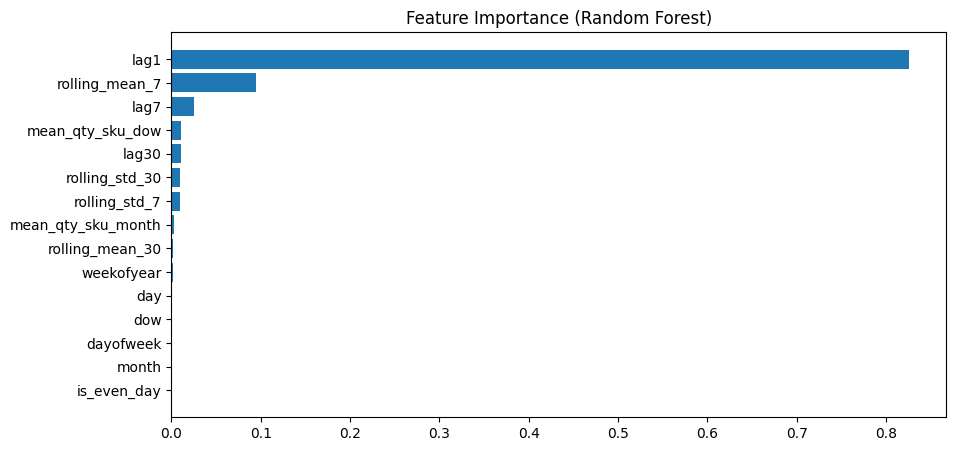

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

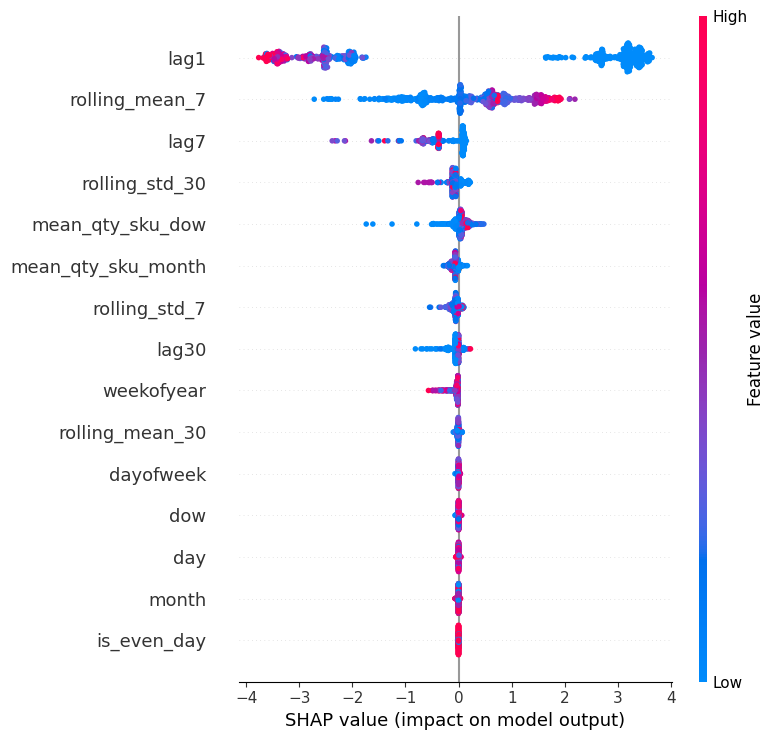

In [ ]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test)

In [ ]:

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

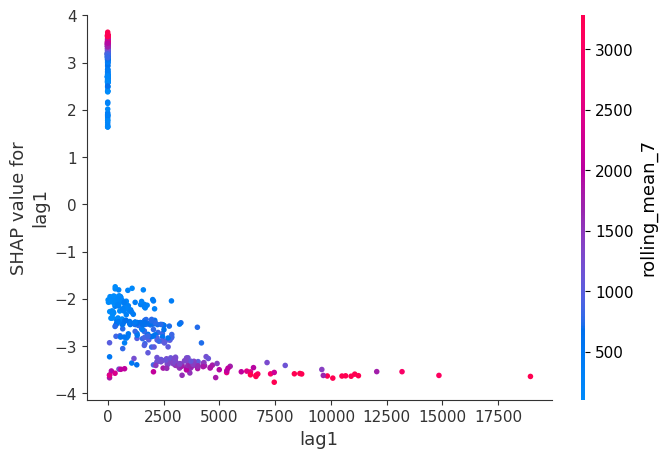

In [ ]:
shap.dependence_plot("lag1", shap_values, X_test)

#### Try XGBoost: 

In [20]:
model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


model_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
y_pred_xgb = model_xgb.predict(X_test_scaled)
y_pred_xgb_exp = np.expm1(y_pred_xgb)

r2_xgb = r2_score(np.expm1(y_test), y_pred_xgb_exp)
mae_xgb = mean_absolute_error(np.expm1(y_test), y_pred_xgb_exp)
rmse_xgb = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_xgb_exp))
print(f"XGBoost R²: {r2_xgb:.4f}")
print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBoost RMSE: {rmse_xgb:.4f}")

XGBoost R²: -0.2730
XGBoost MAE: 1111.1954
XGBoost RMSE: 2385.9919


### 3. Conclusion: 

1. Model RF have better performance than XGboost model, since the data maybe not complicated enough for using boosting model 
2. Model using the "lag1" feature as the most important feature: the t-1 value affect most to the current value

In [ ]:
# Save artifact of model: 
joblib.dump(rf_model, "rf_final.pkl")

['rf_final.pkl']